# Group 1 - Data Exploration – Bike Rental Dataset

In this notebook, we perform exploratory data exploration on the dataset of a bike rental prediction task.  


1. Basics & overview  
2. Missing and false values 
3. Correlation analysis 
4. Histrogram
5. Summarize


In [1]:
# Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno
from sklearn import datasets
import plotly.express as px 
import scipy.stats as stats

# 1. Basics & overview 

In [2]:
# Import the datasets
test_file = ('BikeRentalDaily_test.csv')
train_file = ('BikeRentalDaily_train.csv')

# read the datasets and merge them together
df1 = pd.read_csv(test_file, sep=';')
df2 = pd.read_csv(train_file, sep=';')
df = pd.concat([df1, df2], ignore_index=True)

# Display the dataframe
df


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,leaflets,price reduction,casual,registered,cnt
0,299,26.10.2011,4.0,0,10,0,3,1,2,19.3667,0.472846,108.06255,0.148642,605,0,404,3490,3894
1,458,02.04.2012,2.0,1,4,0,1,1,1,17.3565,0.427513,75.65220,0.312139,518,0,1208,4728,5936
2,687,17.11.2012,4.0,1,11,0,6,0,1,13.0000,0.326383,81.81255,0.179729,766,0,1313,4316,5629
3,346,12.12.2011,4.0,0,12,0,-1,1,1,9.5333,0.270196,NaN,0.063450,739,0,143,3167,3310
4,291,18.10.2011,4.0,0,10,0,2,1,2,21.3000,0.522721,105.25005,0.110087,463,0,637,4111,4748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,78,19.03.2011,1.0,0,3,0,6,0,1,18.9000,0.466525,56.87505,0.368167,1022,1,1424,1693,3117
728,81,22.03.2011,NaN,0,3,0,2,1,1,17.6667,0.440642,93.68745,0.225750,551,0,460,2243,2703
729,377,12.01.2012,1.0,1,1,0,4,1,2,15.3000,0.381938,120.43755,0.180967,520,0,269,3828,4097
730,299,26.10.2011,4.0,0,10,0,3,1,2,19.3667,0.472846,108.06255,0.148642,605,0,404,3490,3894


### Bike Rental Dataset size
- 732 rows
- 18 columns

 ### Bike Sharing Dataset Dictionary

| # | Attribute | Description |
|---|---|---|
| 1 | `instant` | record index |
| 2 | `dteday` | date |
| 3 | `season` | 1:winter, 2:spring, 3:summer, 4:fall |
| 4 | `yr` | year |
| 5 | `mnth` | month (1 to 12) |
| 6 | `holiday` | whether day is holiday or not |
| 7 | `weekday` | day of the week |
| 8 | `workingday` | if day is neither weekend nor holiday is 1, otherwise is 0. |
| 9 | `weathersit` | **1:** Clear, Few clouds, Partly cloudy <br> **2:** Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist <br> **3:** Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds <br> **4:** Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog |
| 10 | `temp` | Temperature |
| 11 | `atemp` | Feeling temperature |
| 12 | `hum` | Humidity |
| 13 | `windspeed` | Wind speed |
| 14 | `leaflets` | Number of distributed leaflets (for marketing purposes) |
| 15 | `price reduction` | Day with price reduction (yes = 1, no = 0) |
| 16 | `casual` | count of casual users |
| 17 | `registered` | count of registered users |
| 18 | `cnt` | count of total rental bikes including both casual and registered |

In [3]:
# dataframe description
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,leaflets,price reduction,casual,registered,cnt
count,732.000000,659.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,692.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,365.908470,2.476480,0.500000,6.524590,0.028689,2.867486,0.684426,1.396175,19.814779,0.474352,93.808823,0.183994,741.775956,0.153005,1058.079235,3655.945355,4714.024590
std,211.035856,1.112505,0.500342,3.451948,0.167044,2.095577,0.465062,0.544980,7.317049,0.162850,21.381071,0.117027,166.967863,0.360239,2862.520234,1559.200902,3506.692931
min,1.000000,1.000000,0.000000,1.000000,0.000000,-1.000000,0.000000,1.000000,2.365200,0.079070,0.000000,-1.000000,458.000000,0.000000,2.000000,20.000000,22.000000
25%,183.750000,1.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.491675,0.337891,77.841075,0.134341,598.000000,0.000000,315.750000,2499.000000,3157.500000
50%,365.500000,2.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,19.933300,0.485158,93.350550,0.179727,739.500000,0.000000,711.500000,3660.000000,4544.500000
75%,548.250000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.208325,0.608289,109.390650,0.233205,887.000000,0.000000,1095.500000,4769.750000,5946.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,34.466700,0.840896,145.875000,0.507463,1032.000000,1.000000,47138.000000,6946.000000,53021.000000


# 2. Missing and false values

### Missing value

In [4]:
 # Count missing values per column
df.isnull().sum()

instant             0
dteday              0
season             73
yr                  0
mnth                0
holiday             0
weekday             0
workingday          0
weathersit          0
temp                0
atemp               0
hum                40
windspeed           0
leaflets            0
price reduction     0
casual              0
registered          0
cnt                 0
dtype: int64

<Axes: >

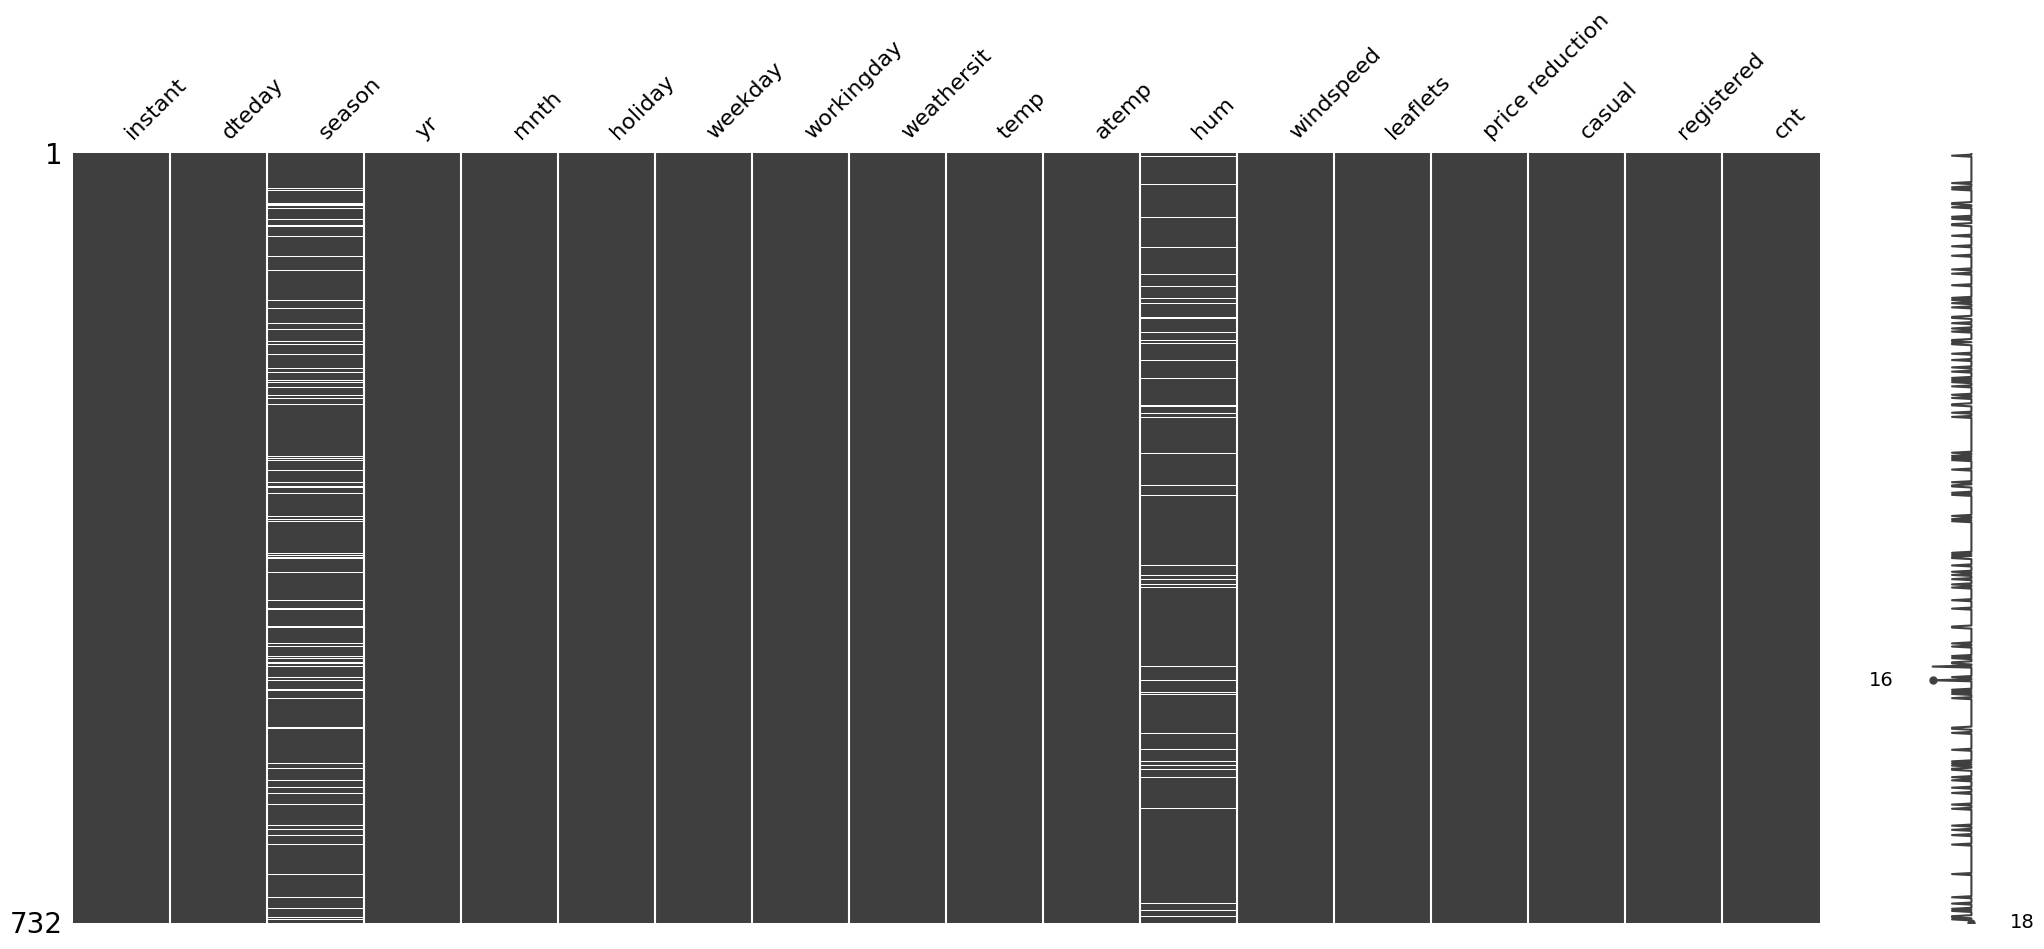

In [5]:
# Visualize missing values (matrix)
msno.matrix(df)

### Identify and display anomalies

- Rows where false values are set to -1

In [6]:
# Rows where false values are set to -1
df_false = df[(df['weekday'] == -1) | (df['windspeed'] == -1)]
df_false.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,leaflets,price reduction,casual,registered,cnt
3,346,12.12.2011,4.0,0,12,0,-1,1,1,9.5333,0.270196,NaN,0.063450,739,0,143,3167,3310
37,61,02.03.2011,1.0,0,3,0,-1,1,1,13.4000,0.320071,67.43745,0.307833,694,0,231,1903,2134
54,347,13.12.2011,4.0,0,12,0,-1,1,1,11.3000,0.301138,88.50000,0.140550,529,0,155,3368,3523
57,350,16.12.2011,4.0,0,12,0,-1,1,2,15.0000,0.359825,75.06255,0.260575,1007,0,178,3399,3577
64,409,13.02.2012,1.0,1,2,0,-1,1,1,8.9000,0.227913,61.68750,0.167283,830,0,94,3328,3422


- Rows where 'hum' > 100

In [7]:
# Rows where 'hum' > 100
df_hum_over_100 = df[df['hum'] > 100]
df_hum_over_100.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,leaflets,price reduction,casual,registered,cnt
0,299,26.10.2011,4.0,0,10,0,3,1,2,19.3667,0.472846,108.06255,0.148642,605,0,404,3490,3894
4,291,18.10.2011,4.0,0,10,0,2,1,2,21.3000,0.522721,105.25005,0.110087,463,0,637,4111,4748
9,201,20.07.2011,3.0,0,7,0,3,1,1,30.7333,0.746850,106.06245,0.113817,753,1,644,3688,4332
15,579,01.08.2012,3.0,1,8,0,3,1,1,28.7000,0.667308,101.62500,0.141179,896,0,1074,6506,7580
17,388,23.01.2012,1.0,1,1,0,1,1,2,8.7333,0.243058,136.68750,0.110708,633,0,145,2287,2432


- Unique values in 'weathersit' is missing '4'

In [8]:
# Unique values in 'weathersit' is missing '4'
print("\n--- Unique values in 'weathersit' (to see '4' is missing) ---")
print(df['weathersit'].unique())


--- Unique values in 'weathersit' (to see '4' is missing) ---
[2 1 3]


- Unique values in 'weekday' is missing '7'

In [9]:
# Unique values in 'weekday' is missing '7'
print("\n--- Unique values in 'weekday' (to see '7' is missing) ---")
print(df['weekday'].unique())


--- Unique values in 'weekday' (to see '7' is missing) ---
[ 3  1  6 -1  2  4  0  5]


- Boxplot for 'casual' and 'cnt' columns to visualize outliers

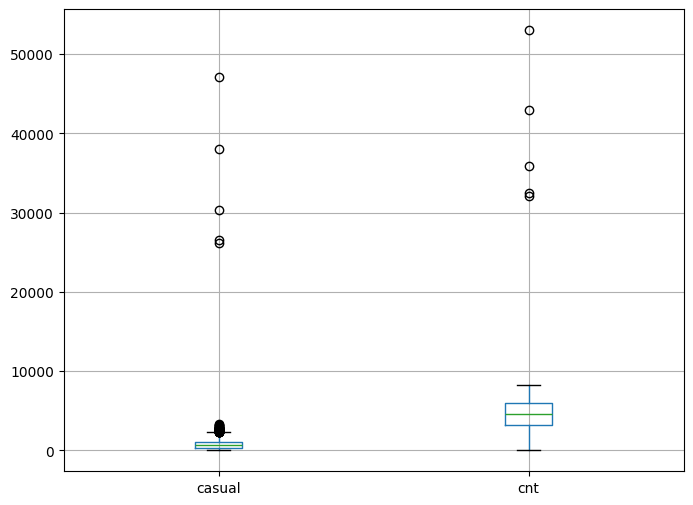

In [10]:
# Boxplot for 'casual' and 'cnt' columns to visualize outliers
boxplot_fales_value = df[['casual','cnt']].iloc[:,:].boxplot(figsize=(8, 6))

## 3. Correlation analysis 

### Heatmaps correlation check

<Axes: >

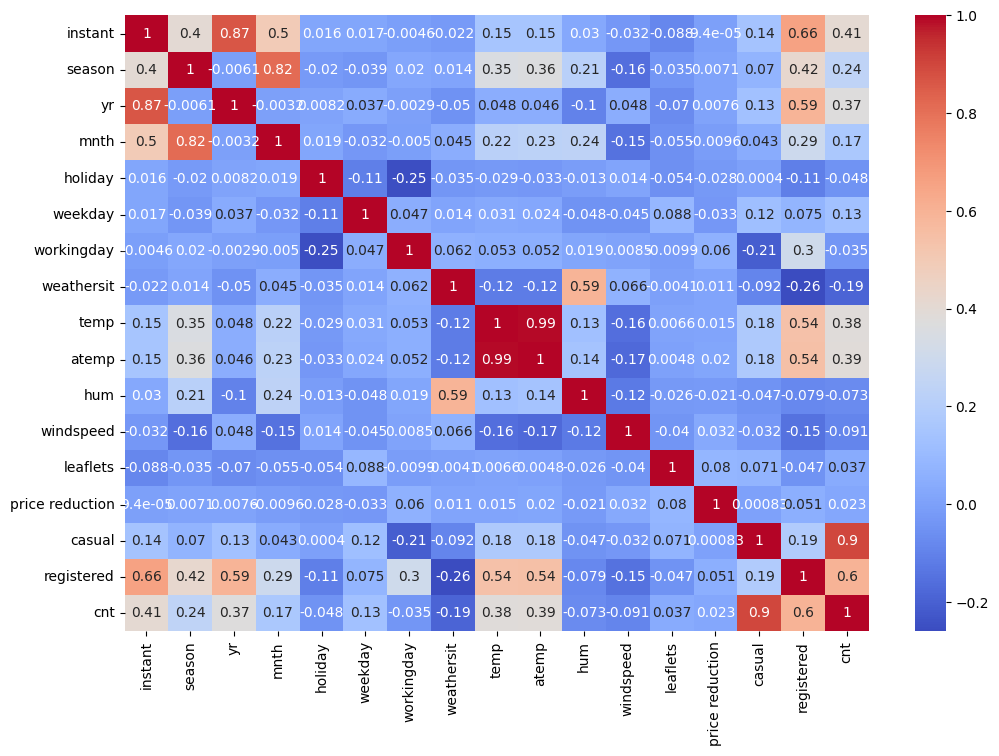

In [11]:
# Heatmaps correlation check
df_HM = df
# drop 'dteday' column for correlation analysis
df_HM.drop(['dteday'], axis=1, inplace=True)

# Calculate correlation matrix and plot heatmap
corr = df_HM.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True)

### Before going next step. We need to delete some missing value first

In [12]:
# Remove outliers in 'casual' column (values greater than 10000)
df = df[df['casual'] <= 10000]

Problem: instant shouldn’t be correlate with any data

- temp and atemp correlate to each other

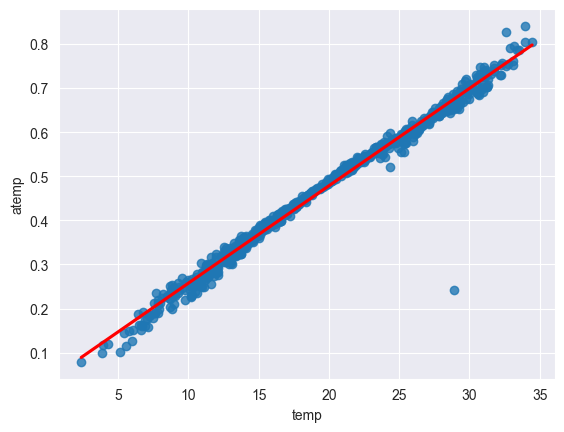

In [13]:
# set style
sns.set_style("darkgrid")

# Scatter plot with regression line for 'temp' and 'atemp'
sns.regplot(
    data=df,  
    x='temp', 
    y='atemp',  
    ci=None,  
    line_kws={'color':'red'} 
)

# Show the plot
plt.show()

- season and month correlate to each other

In [14]:
# Parallel Coordinates Plot to visualize correlation between 'season' and 'mnth'
fig = px.parallel_coordinates(df, color="mnth",
                              dimensions=['season','mnth'],
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              color_continuous_midpoint=2,
                              )

# Show the plot
fig.show()

- hum and windspeed is correlation

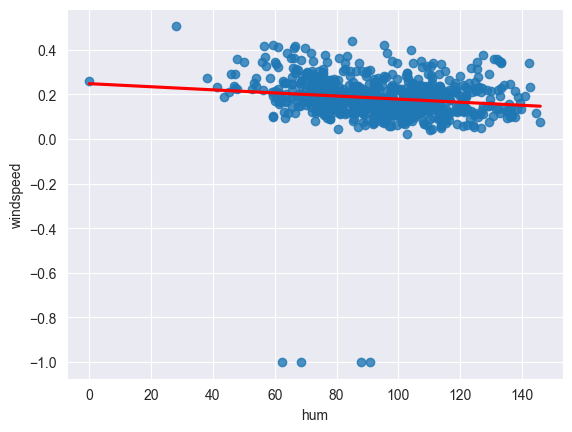

In [15]:
# Scatter plot with regression line for 'hum' and 'windspeed'
sns.regplot(
    data=df,  
    x='hum', 
    y='windspeed',  
    ci=None,  
    line_kws={'color':'red'} 
)

# Show the plot
plt.show()

- Casual, registered correlation  to cnt

In [16]:
# Parallel Coordinates Plot to visualize correlation between 'casual', 'registered' and 'cnt'
fig = px.parallel_coordinates(df, color="cnt",
                              dimensions=['casual','registered','cnt'],
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              color_continuous_midpoint=2,
                              )

# Show the plot
fig.show()

- cnt correlation with atemp and weathersit

In [26]:
# Parallel Coordinates Plot to visualize correlation between 'weathersit' and 'cnt'
fig = px.parallel_coordinates(df, color="cnt",
                              dimensions=['weathersit','cnt'],
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              color_continuous_midpoint=2,
                              )

# Show the plot
fig.show()

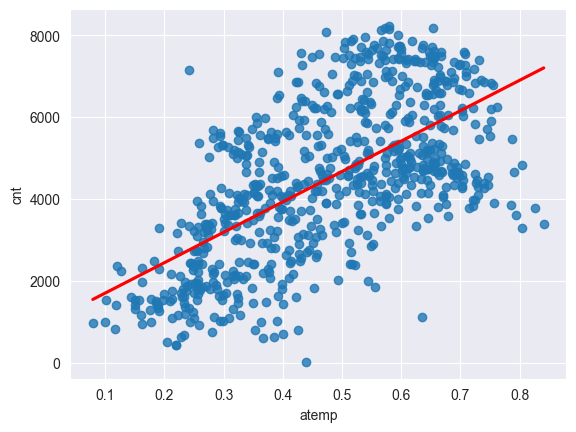

In [27]:
# Scatter plot with regression line for 'atemp' and 'cnt'
sns.regplot(
    data=df,  
    x='atemp', 
    y='cnt',  
    ci=None,  
    line_kws={'color':'red'} 
)

# Show the plot
plt.show()

- leaflets and price reduction didn’t correlation to cnt

In [29]:
# Parallel Coordinates Plot to visualize correlation between 'leaflets', 'price reduction' and 'cnt'
fig = px.parallel_coordinates(df, color="cnt",
                              dimensions=['cnt', 'leaflets', 'price reduction'],
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              color_continuous_midpoint=2,
                              )

# Show the plot
fig.show()

# 4. Histrogram

array([[<Axes: title={'center': 'instant'}>,
        <Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'yr'}>, <Axes: title={'center': 'mnth'}>],
       [<Axes: title={'center': 'holiday'}>,
        <Axes: title={'center': 'weekday'}>,
        <Axes: title={'center': 'workingday'}>,
        <Axes: title={'center': 'weathersit'}>],
       [<Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'hum'}>,
        <Axes: title={'center': 'windspeed'}>],
       [<Axes: title={'center': 'leaflets'}>,
        <Axes: title={'center': 'price reduction'}>,
        <Axes: title={'center': 'casual'}>,
        <Axes: title={'center': 'registered'}>],
       [<Axes: title={'center': 'cnt'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

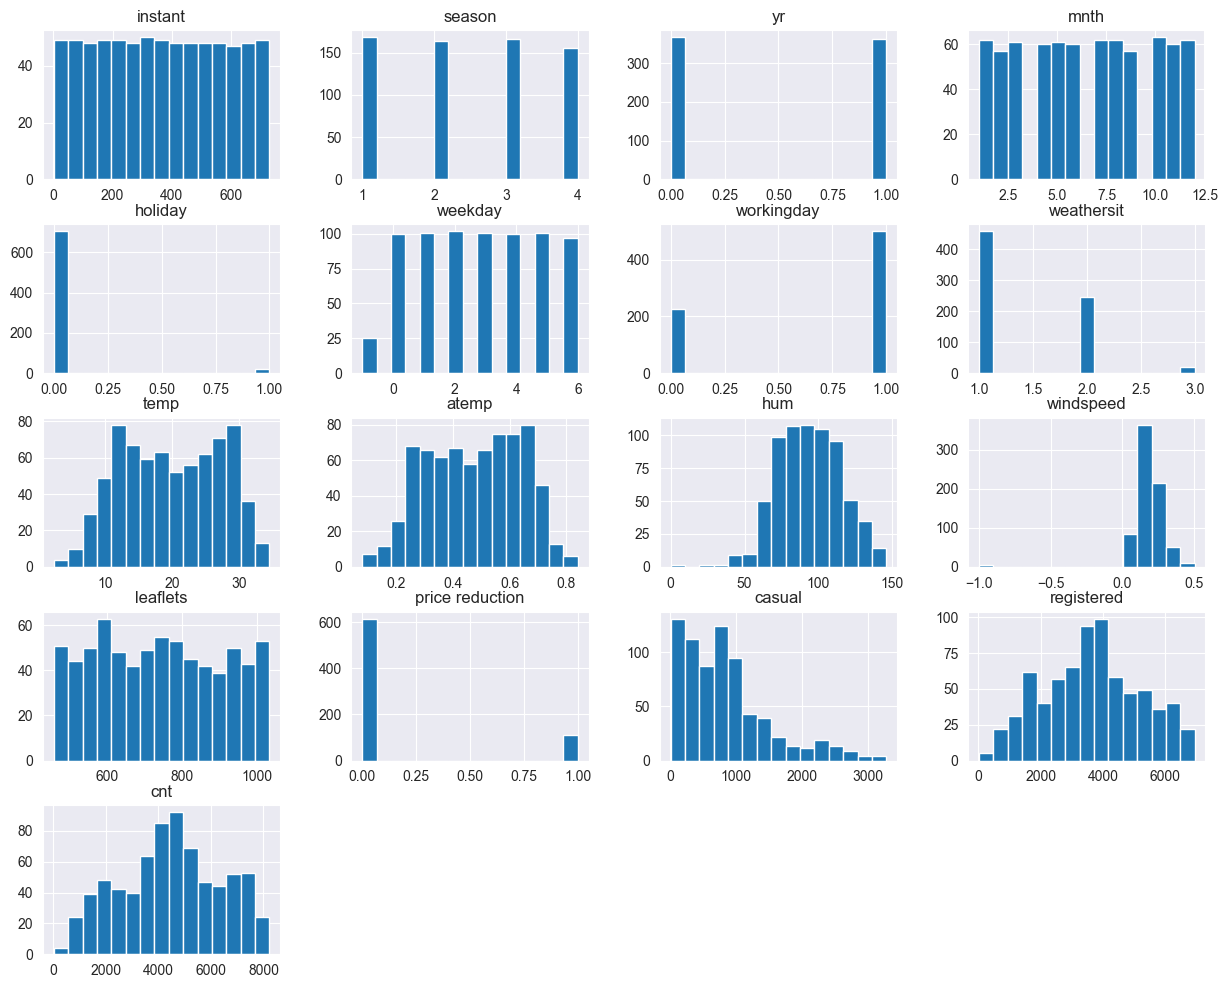

In [35]:
# Show all histograms
hist = df.hist(bins=15,figsize=(15, 12))
hist

- have only few user in Holiday and price reduction days

array([[<Axes: title={'center': 'holiday'}>,
        <Axes: title={'center': 'price reduction'}>]], dtype=object)

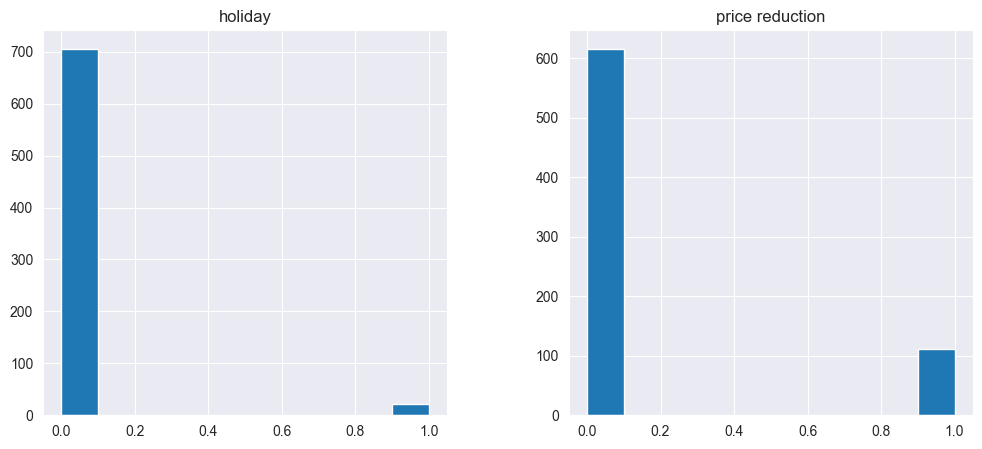

In [ ]:
# only few user in Holiday and price reduction days
hist = df_filtered.hist(column=['holiday','price reduction'],figsize=(12, 5))
# show
hist

# 5. Summarize

### Point out Data issues

* Missing values: `season` and `humidity`
* Outliers: `weatherset`, `humidity` (> 100), `weekday` (-1) `casual` and `cnt`
* Features to be transformed: `Date` (Change format or delete), `instant` (might damage machine learning)
* Features to be removed: `Temp` (duplicate with `aTemp`), `Date`

### Interesting insight

* `temp` and `atemp` correlate to each other
* `season` close to `month`
* `casual`, `registered` correlation to `cnt`
* `cnt` correlation with `atemp` and `weathersit`
* `humidity` close to `windspeed`
* have only few user in Holiday and price reduction days
* leaflets and price reduction **didn't correlation** to `cnt`